# ANOVA
Analysis of variance (ANOVA) is a family of statistical methods used to compare the means of two or more groups by analyzing variance.

## One-Way ANOVA

Question: Do average incomes differ across education levels?

Hypothesis:
- $H_0$: All group means are equal ($\mu_1=\mu_2=\mu_3$)
- $H_1$: At least one group mean is different.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("../05-data_cleaning/data/nls97.csv")
df.head()

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
1,100139,Male,9,1983,12.0,Married,2.0,0.0,120000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
2,100284,Male,11,1984,7.0,Never-married,1.0,0.0,58000.0,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
3,100292,Male,4,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,NaN,NaN,NaN,NaN
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled


In [2]:
df['highestdegree'].value_counts()

highestdegree
2. High School     3667
4. Bachelors       1673
1. GED             1146
0. None             953
3. Associates       737
5. Masters          603
7. Professional     120
6. PhD               54
Name: count, dtype: int64

Inspect the data, we found there are 8 type of `highestdegree`. Perhaps let's focus on three groups: high school, bachelor, masters.

In [3]:
df_clean = df[["wageincome", "highestdegree"]].dropna()

group1 = df_clean[df_clean["highestdegree"] == "2. High School"]["wageincome"]
group2 = df_clean[df_clean["highestdegree"] == "4. Bachelors"]["wageincome"]
group3 = df_clean[df_clean["highestdegree"] == "5. Masters"]["wageincome"]

In [4]:
# run ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 196.68524880313575
p-value: 7.795841199054804e-82


In [5]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: At least one group mean is different")
else:
    print("Fail to reject H0: No significant difference among groups")

Reject H0: At least one group mean is different


<Axes: xlabel='wageincome', ylabel='Density'>

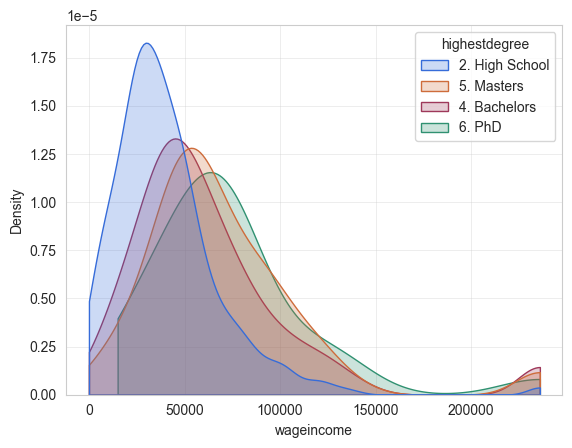

In [7]:
# we can inspect incomes by education visually to have a general sense
sns.set_style("whitegrid")
sns.kdeplot(data=df_clean[df_clean['highestdegree'].isin([
    "2. High School", "4. Bachelors", "5. Masters", "6. PhD"
])], x='wageincome', hue='highestdegree',fill=True, cut=0, common_norm=False)

In [ ]:
# Check Group Means
print(df_clean.groupby("highestdegree")["wageincome"].mean())

## which group differ?
Use `statsmodels`'s `pairwise_tukeyhsd`, which calculate all pairwise comparisons with TukeyHSD or Games-Howell.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_clean[df_clean['highestdegree'].isin([
    "2. High School", "4. Bachelors", "5. Masters", "6. PhD"
])]['wageincome'],
    groups=df_clean[df_clean['highestdegree'].isin([
    "2. High School", "4. Bachelors", "5. Masters", "6. PhD"
])]['highestdegree'],
    alpha=0.05
)

print(tukey)